In [37]:
# Import libraries
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_geom
from rasterio.transform import Affine
import tensorflow as tf
import os
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd

In [3]:
#derived data products from paper
dtd = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif')
hs = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif')
at = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif')
ecc = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif')
crs = "EPSG:3857"
res = 1000.0
beaufort = gpd.read_file('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/NAIP Imagery by County/Beaufort/ortho_1-1_hn_s_nc013_2022_1/ortho_1-1_hn_nc013_2022_1.shp')

In [4]:
treedensity_2022 = dtd.read(1)
treedensity_2022

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(14271, 8332), dtype=float32)

In [5]:
type(treedensity_2022)

numpy.ndarray

Text(0.5, 1.0, 'Tree Density')

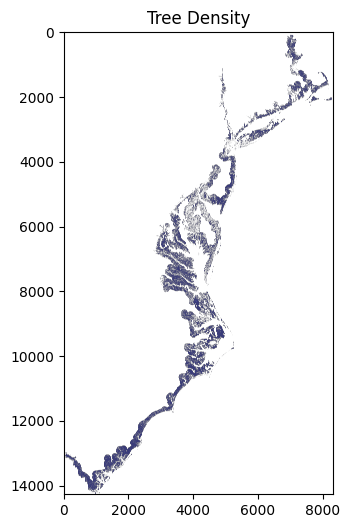

In [6]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(treedensity_2022, cmap='tab20b')
ax.set_title("Tree Density", fontsize=12)

In [7]:
nc = {
    "type": "Polygon",
    "coordinates": [[
        [-84.32, 33.84],
        [-84.32, 36.59],
        [-75.46, 36.59],
        [-75.46, 33.84],
        [-84.32, 33.84]
    ]]
}

In [8]:
def reproject_and_downsample(src, dst_crs, res_m):
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs,
        src.width, src.height,
        *src.bounds,
        resolution=res_m
    )

    arr = np.full((height, width), np.nan, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=arr,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs=dst_crs,
        resampling=Resampling.average,
        dst_nodata=np.nan
    )
    return arr, transform

In [9]:
dead_reproj, dead_t = reproject_and_downsample(dtd, crs, res)
hot_reproj,  hot_t  = reproject_and_downsample(hs, crs, res)

In [11]:
#NC cords to crs
nc_proj = transform_geom("EPSG:4326", crs, nc)
coords = nc_proj["coordinates"][0]
xs = [c[0] for c in coords]
ys = [c[1] for c in coords]
nc_bounds = (min(xs), min(ys), max(xs), max(ys))  # (minx, miny, maxx, maxy)

In [12]:
#cropping
def crop(arr, transform, bounds):
    minx, miny, maxx, maxy = bounds
    inv = ~transform

    col_min, row_max = inv * (minx, miny)
    col_max, row_min = inv * (maxx, maxy)

    r0 = max(0, int(np.floor(row_min)))
    r1 = min(arr.shape[0], int(np.ceil(row_max)))
    c0 = max(0, int(np.floor(col_min)))
    c1 = min(arr.shape[1], int(np.ceil(col_max)))

    cropped = arr[r0:r1, c0:c1]

    new_transform = Affine(
        transform.a, transform.b, transform.c + c0 * transform.a,
        transform.d, transform.e, transform.f + r0 * transform.e
    )
    return cropped, new_transform

dead_crop, dead_crop_t = crop(dead_reproj, dead_t, nc_bounds)
hot_crop,  hot_crop_t  = crop(hot_reproj,  hot_t,  nc_bounds)

In [22]:
# hotspots thres
vals = hot_crop[np.isfinite(hot_crop)]
mean_val = np.mean(vals)
std_val  = np.std(vals)
threshold = mean_val + std_val

hot_mask = np.where(hot_crop > threshold, 1, 0)

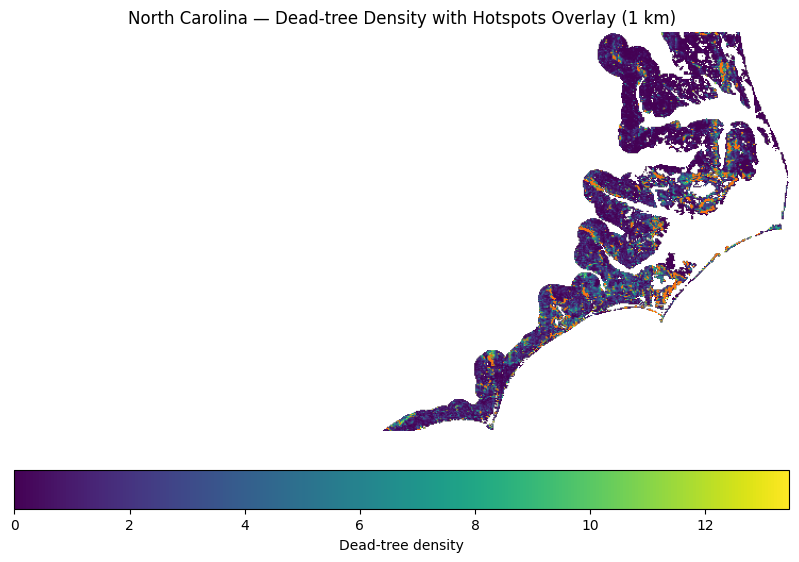

In [31]:
#hotspot plus dtd plot
plt.figure(figsize=(10,10))

vmin, vmax = np.nanpercentile(dead_crop, [5, 95])
im = plt.imshow(dead_crop, origin='upper', vmin=vmin, vmax=vmax)

cbar = plt.colorbar(im, orientation="horizontal", pad=0.05)
cbar.set_label("Dead-tree density")

# hotspot overlay
overlay = np.zeros((hot_mask.shape[0], hot_mask.shape[1], 4))
overlay[..., 0] = hot_mask       
overlay[..., 3] = hot_mask * 0.5  
plt.imshow(overlay, origin='upper')

plt.title("North Carolina — Dead-tree Density with Hotspots Overlay (1 km)")
plt.axis("off")
plt.show()
